In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np

# Broadcast style
plt.rcParams['figure.facecolor'] = '#0a0a2e'
plt.rcParams['text.color'] = 'white'
plt.rcParams['axes.facecolor'] = '#0a0a2e'
plt.rcParams['axes.labelcolor'] = 'white'
plt.rcParams['xtick.color'] = 'white'
plt.rcParams['ytick.color'] = 'white'

# Load all datasets
batting = pd.read_csv(r'D:\Growth\ICC-T20-WC-2026\batting_stats.csv')
bowling = pd.read_csv(r'D:\Growth\ICC-T20-WC-2026\bowling_stats.csv')
matches = pd.read_csv(r'D:\Growth\ICC-T20-WC-2026\matches.csv')
points = pd.read_csv(r'D:\Growth\ICC-T20-WC-2026\points_table.csv')
awards = pd.read_csv(r'D:\Growth\ICC-T20-WC-2026\awards.csv')

print("✅ All files loaded!")
print(f"Batting players: {len(batting)}")
print(f"Bowling players: {len(bowling)}")
print(f"Total matches: {len(matches)}")
print("\nBatting columns:", batting.columns.tolist())
print("Bowling columns:", bowling.columns.tolist())

✅ All files loaded!
Batting players: 19
Bowling players: 15
Total matches: 55

Batting columns: ['player', 'team', 'matches', 'innings', 'runs', 'average', 'strike_rate', 'fours', 'sixes', 'hundreds', 'fifties']
Bowling columns: ['player', 'team', 'matches', 'overs', 'balls', 'wickets', 'average', 'runs_conceded', 'economy', 'four_wicket_hauls', 'five_wicket_hauls', 'best_figures']


In [2]:
# Fix the South Africa vs India result
# Match 46: India vs South Africa — India actually LOST
matches.loc[
    (matches['team1'] == 'India') & 
    (matches['team2'] == 'South Africa') &
    (matches['stage'] == 'Super Eight'),
    'winner'
] = 'South Africa'

print("✅ Result corrected!")

# Verify
india_matches = matches[
    (matches['team1'] == 'India') | 
    (matches['team2'] == 'India')
]
india_wins = india_matches[
    india_matches['winner'] == 'India'
].shape[0]
print(f"India corrected wins: {india_wins}")

✅ Result corrected!
India corrected wins: 8


C:\Users\jagruti\AppData\Local\Temp\ipykernel_16932\29453856.py:50: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\jagruti\AppData\Local\Temp\ipykernel_16932\29453856.py:51: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.savefig(r'D:\Growth\ICC-T20-WC-2026\top_run_scorers.png',
C:\Users\jagruti\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


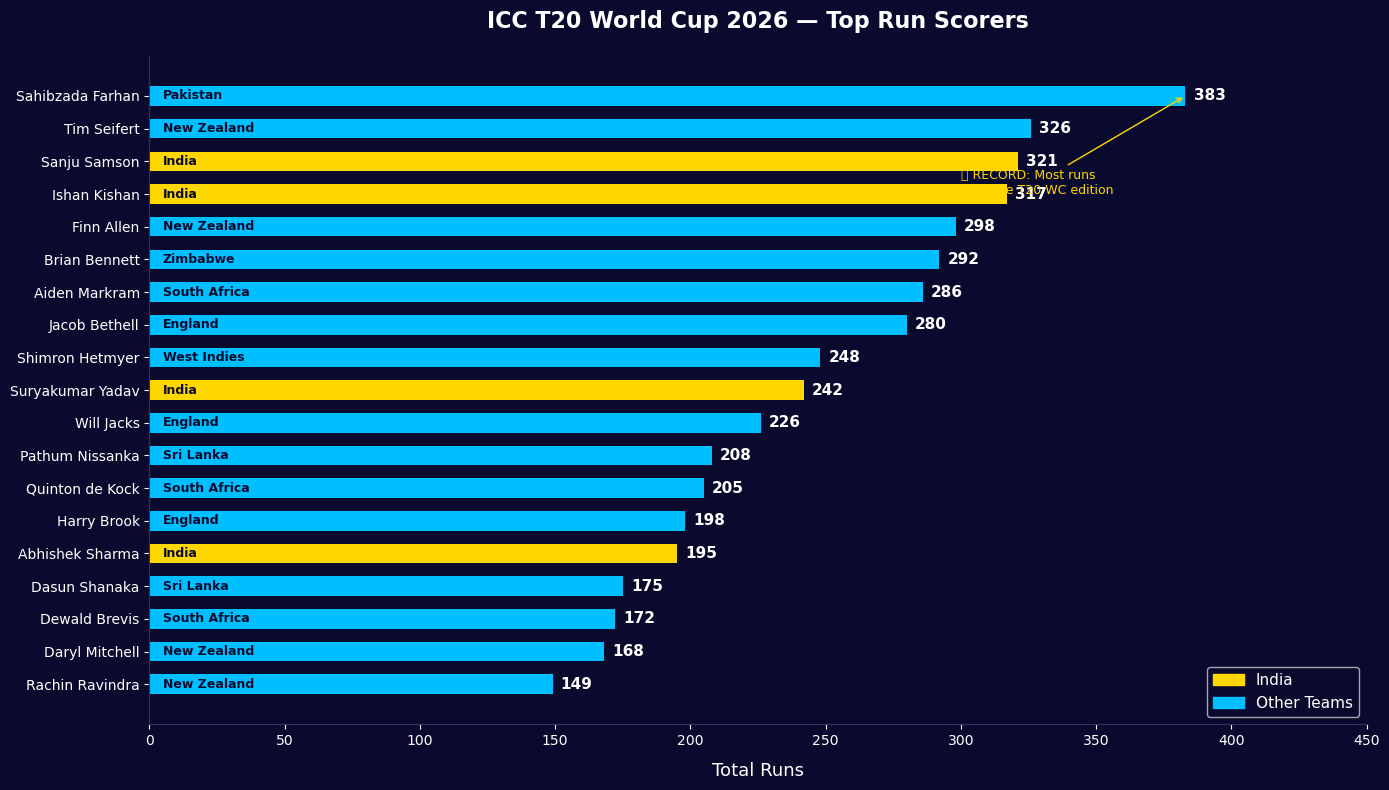

✅ Chart 1 saved!


In [3]:
fig, ax = plt.subplots(figsize=(14, 8))
fig.patch.set_facecolor('#0a0a2e')
ax.set_facecolor('#0a0a2e')

# Sort by runs
batting_sorted = batting.sort_values('runs', ascending=True)

# Color India players gold, others white
colors = ['#FFD700' if team == 'India' else '#00BFFF' 
          for team in batting_sorted['team']]

bars = ax.barh(batting_sorted['player'], batting_sorted['runs'], 
               color=colors, height=0.6)

# Add run labels
for bar, runs, team in zip(bars, batting_sorted['runs'], 
                            batting_sorted['team']):
    ax.text(bar.get_width() + 3, bar.get_y() + bar.get_height()/2,
            str(runs), va='center', fontsize=11, 
            color='white', fontweight='bold')

# Add team labels inside bars
for bar, player, team in zip(bars, batting_sorted['player'],
                              batting_sorted['team']):
    ax.text(5, bar.get_y() + bar.get_height()/2,
            team, va='center', fontsize=9,
            color='#0a0a2e', fontweight='bold')

ax.set_xlabel('Total Runs', fontsize=13, color='white', labelpad=10)
ax.set_title('ICC T20 World Cup 2026 — Top Run Scorers', 
             fontsize=16, color='white', fontweight='bold', pad=20)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#333366')
ax.spines['bottom'].set_color('#333366')
ax.set_xlim(0, 450)

# Legend
gold = mpatches.Patch(color='#FFD700', label='India')
blue = mpatches.Patch(color='#00BFFF', label='Other Teams')
ax.legend(handles=[gold, blue], loc='lower right', 
          facecolor='#0a0a2e', labelcolor='white', fontsize=11)

# Add record annotation
ax.annotate('🏆 RECORD: Most runs\nin single T20 WC edition',
            xy=(383, 18), xytext=(300, 15),
            fontsize=9, color='#FFD700',
            arrowprops=dict(arrowstyle='->', color='#FFD700'))

plt.tight_layout()
plt.savefig(r'D:\Growth\ICC-T20-WC-2026\top_run_scorers.png', 
            dpi=150, bbox_inches='tight',
            facecolor='#0a0a2e')
plt.show()
print("✅ Chart 1 saved!")

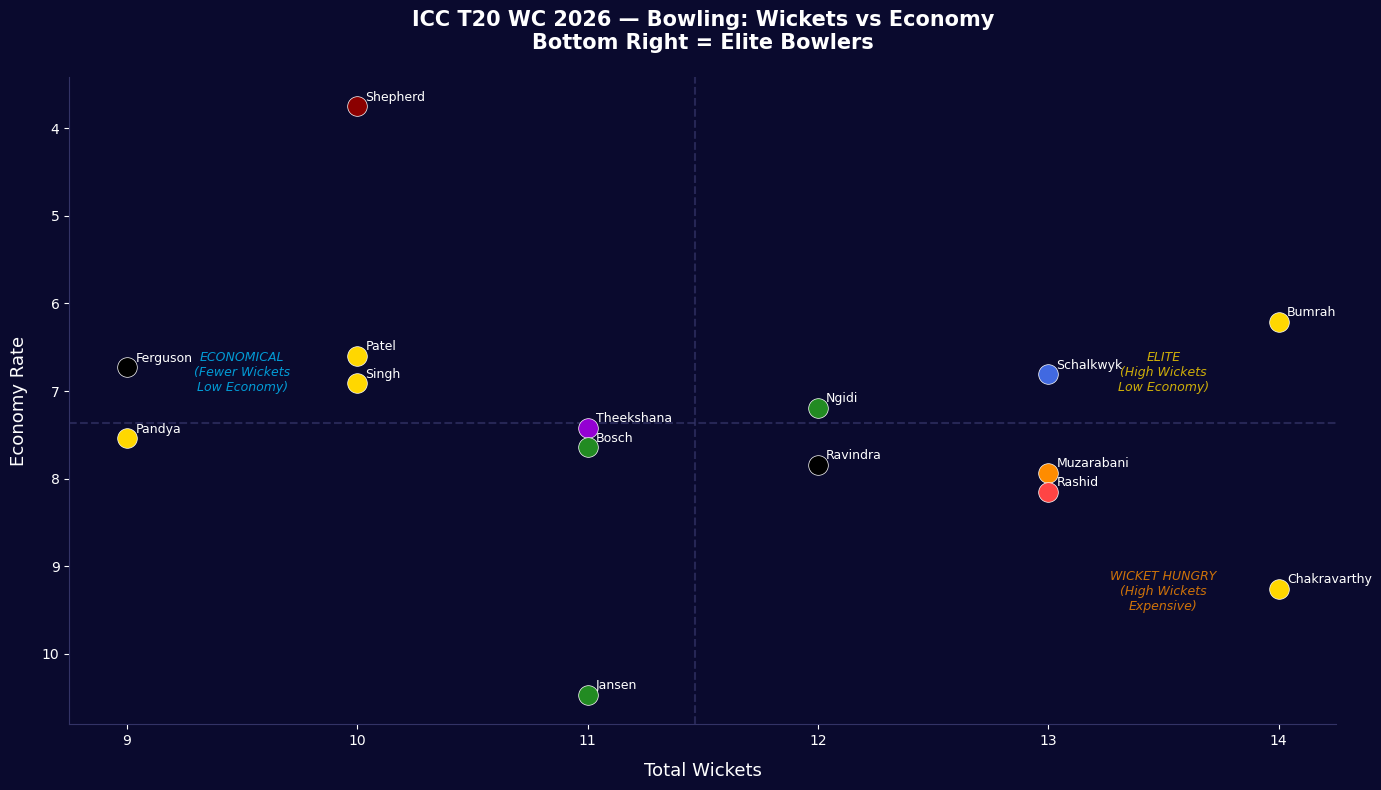

✅ Chart 2 saved!


In [4]:
fig, ax = plt.subplots(figsize=(14, 8))
fig.patch.set_facecolor('#0a0a2e')
ax.set_facecolor('#0a0a2e')

# Color by team
team_colors = {
    'India': '#FFD700',
    'New Zealand': '#000000',
    'South Africa': '#228B22',
    'England': '#FF4444',
    'West Indies': '#8B0000',
    'Pakistan': '#006400',
    'Zimbabwe': '#FF8C00',
    'USA': '#4169E1',
    'Sri Lanka': '#9400D3'
}

for _, row in bowling.iterrows():
    color = team_colors.get(row['team'], '#00BFFF')
    ax.scatter(row['wickets'], row['economy'], 
               s=200, color=color, zorder=5,
               edgecolors='white', linewidth=0.5)
    ax.annotate(row['player'].split()[-1],
                (row['wickets'], row['economy']),
                textcoords='offset points',
                xytext=(6, 4),
                fontsize=9, color='white')

# Quadrant lines
ax.axvline(x=bowling['wickets'].mean(), 
           color='#333366', linestyle='--', alpha=0.7)
ax.axhline(y=bowling['economy'].mean(), 
           color='#333366', linestyle='--', alpha=0.7)

# Quadrant labels
ax.text(13.5, 7.0, 'ELITE\n(High Wickets\nLow Economy)', 
        fontsize=9, color='#FFD700', alpha=0.8,
        ha='center', style='italic')
ax.text(9.5, 7.0, 'ECONOMICAL\n(Fewer Wickets\nLow Economy)', 
        fontsize=9, color='#00BFFF', alpha=0.8,
        ha='center', style='italic')
ax.text(13.5, 9.5, 'WICKET HUNGRY\n(High Wickets\nExpensive)', 
        fontsize=9, color='#FF8C00', alpha=0.8,
        ha='center', style='italic')

ax.set_xlabel('Total Wickets', fontsize=13, 
              color='white', labelpad=10)
ax.set_ylabel('Economy Rate', fontsize=13, 
              color='white', labelpad=10)
ax.set_title('ICC T20 WC 2026 — Bowling: Wickets vs Economy\n'
             'Bottom Right = Elite Bowlers', 
             fontsize=15, color='white', 
             fontweight='bold', pad=20)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#333366')
ax.spines['bottom'].set_color('#333366')
ax.tick_params(colors='white')

# Invert y axis — lower economy = better
ax.invert_yaxis()

plt.tight_layout()
plt.savefig(r'D:\Growth\ICC-T20-WC-2026\bowling_efficiency.png',
            dpi=150, bbox_inches='tight',
            facecolor='#0a0a2e')
plt.show()
print("✅ Chart 2 saved!")

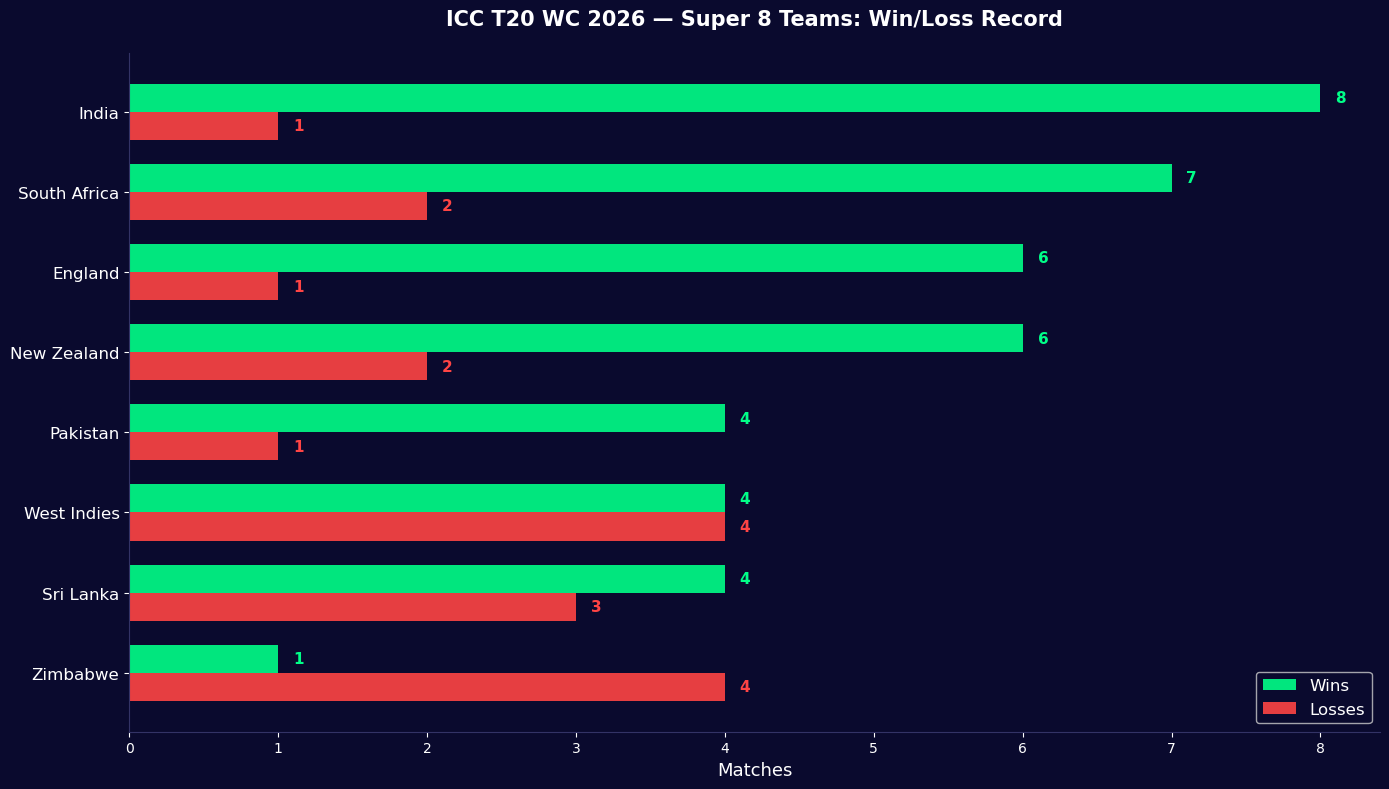

✅ Chart 3 saved!


In [5]:
# Filter only main teams that made Super 8
super8_teams = ['India', 'England', 'South Africa', 'New Zealand',
                'West Indies', 'Zimbabwe', 'Pakistan', 'Sri Lanka']

team_stats = []
for team in super8_teams:
    team_matches = matches[
        (matches['team1'] == team) | (matches['team2'] == team)
    ]
    wins = team_matches[team_matches['winner'] == team].shape[0]
    total = team_matches[
        team_matches['winner'] != 'No Result'
    ].shape[0]
    losses = total - wins
    team_stats.append({
        'team': team,
        'wins': wins,
        'losses': losses,
        'win_pct': round(wins * 100 / total, 1) if total > 0 else 0
    })

team_df = pd.DataFrame(team_stats).sort_values('wins', ascending=True)

fig, ax = plt.subplots(figsize=(14, 8))
fig.patch.set_facecolor('#0a0a2e')
ax.set_facecolor('#0a0a2e')

x = np.arange(len(team_df))
width = 0.35

bars1 = ax.barh(x + width/2, team_df['wins'], 
                width, label='Wins', 
                color='#00FF88', alpha=0.9)
bars2 = ax.barh(x - width/2, team_df['losses'], 
                width, label='Losses', 
                color='#FF4444', alpha=0.9)

# Add labels
for bar in bars1:
    ax.text(bar.get_width() + 0.1, 
            bar.get_y() + bar.get_height()/2,
            str(int(bar.get_width())), 
            va='center', color='#00FF88', 
            fontweight='bold', fontsize=11)
for bar in bars2:
    ax.text(bar.get_width() + 0.1,
            bar.get_y() + bar.get_height()/2,
            str(int(bar.get_width())),
            va='center', color='#FF4444',
            fontweight='bold', fontsize=11)

ax.set_yticks(x)
ax.set_yticklabels(team_df['team'], fontsize=12, color='white')
ax.set_xlabel('Matches', fontsize=13, color='white')
ax.set_title('ICC T20 WC 2026 — Super 8 Teams: Win/Loss Record',
             fontsize=15, color='white', 
             fontweight='bold', pad=20)
ax.legend(facecolor='#0a0a2e', labelcolor='white', 
          fontsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#333366')
ax.spines['bottom'].set_color('#333366')

plt.tight_layout()
plt.savefig(r'D:\Growth\ICC-T20-WC-2026\team_journey.png',
            dpi=150, bbox_inches='tight',
            facecolor='#0a0a2e')
plt.show()
print("✅ Chart 3 saved!")

C:\Users\jagruti\AppData\Local\Temp\ipykernel_16932\1683073205.py:49: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(players_data['player'].str.split().str[-1],
C:\Users\jagruti\AppData\Local\Temp\ipykernel_16932\1683073205.py:62: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(players_data['player'].str.split().str[-1],


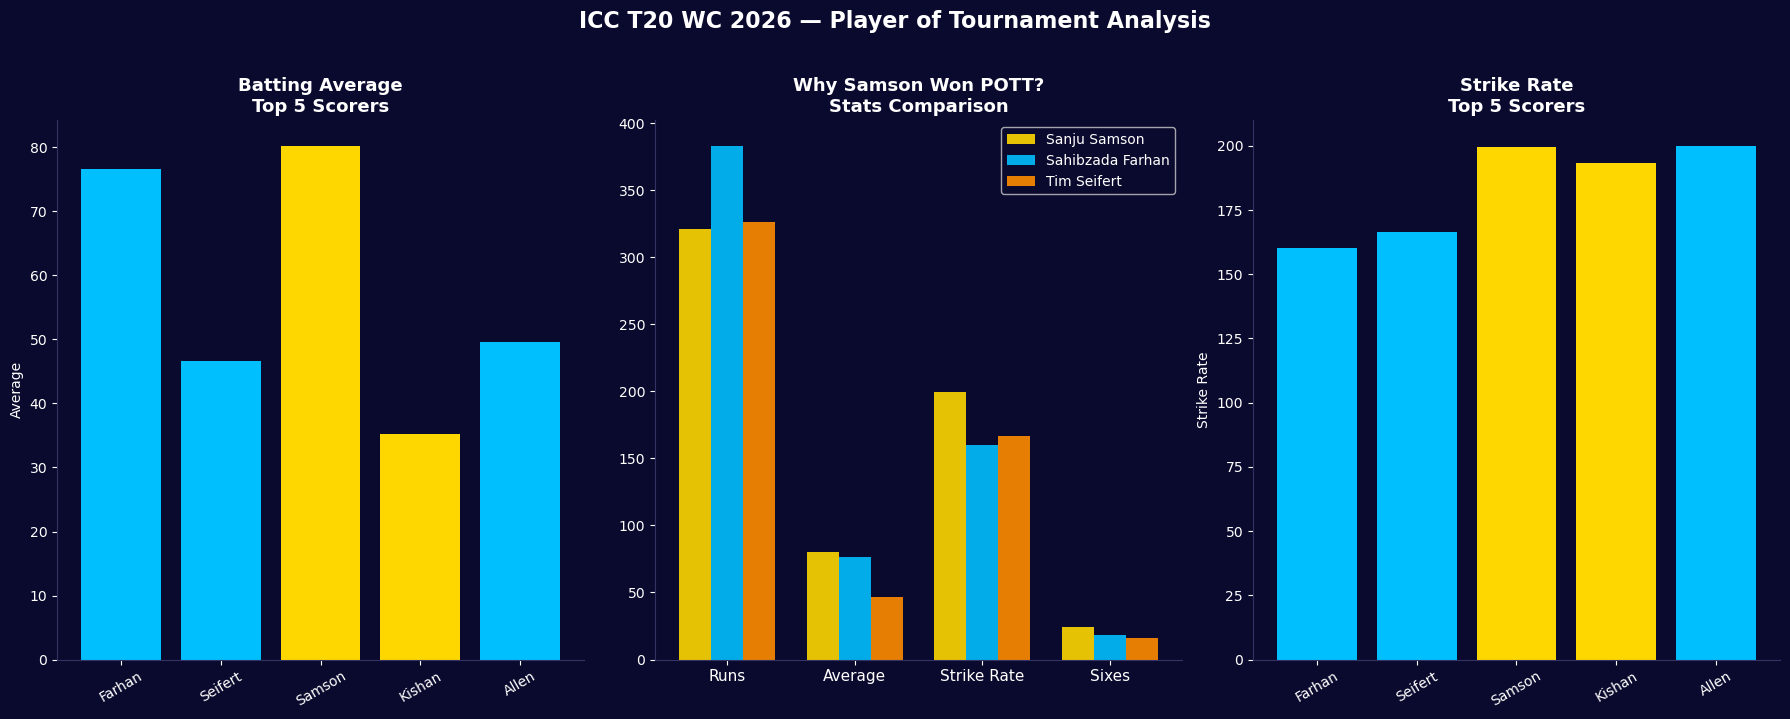

✅ Chart 4 saved!


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 7))
fig.patch.set_facecolor('#0a0a2e')

# Sanju Samson stats
samson = batting[batting['player'] == 'Sanju Samson'].iloc[0]
farhan = batting[batting['player'] == 'Sahibzada Farhan'].iloc[0]
seifert = batting[batting['player'] == 'Tim Seifert'].iloc[0]

categories = ['Runs', 'Average', 'Strike Rate', 'Sixes']
samson_vals = [321, 80.25, 199.38, 24]
farhan_vals = [383, 76.6, 160.25, 18]
seifert_vals = [326, 46.57, 166.33, 16]

x = np.arange(len(categories))
width = 0.25

for i, ax in enumerate(axes):
    ax.set_facecolor('#0a0a2e')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#333366')
    ax.spines['bottom'].set_color('#333366')

# Main comparison chart
ax = axes[1]
b1 = ax.bar(x - width, samson_vals, width, 
            label='Sanju Samson', color='#FFD700', alpha=0.9)
b2 = ax.bar(x, farhan_vals, width,
            label='Sahibzada Farhan', color='#00BFFF', alpha=0.9)
b3 = ax.bar(x + width, seifert_vals, width,
            label='Tim Seifert', color='#FF8C00', alpha=0.9)

ax.set_xticks(x)
ax.set_xticklabels(categories, color='white', fontsize=11)
ax.legend(facecolor='#0a0a2e', labelcolor='white', fontsize=10)
ax.set_title('Why Samson Won POTT?\nStats Comparison',
             color='white', fontsize=13, fontweight='bold')
ax.tick_params(colors='white')

# Matches played vs runs — efficiency
ax = axes[0]
players_data = batting.head(5)
ax.bar(players_data['player'].str.split().str[-1],
       players_data['average'],
       color=['#FFD700' if t == 'India' 
              else '#00BFFF' for t in players_data['team']])
ax.set_title('Batting Average\nTop 5 Scorers',
             color='white', fontsize=13, fontweight='bold')
ax.set_xticklabels(players_data['player'].str.split().str[-1],
                   rotation=30, color='white')
ax.tick_params(colors='white')
ax.set_ylabel('Average', color='white')

# Strike rate comparison
ax = axes[2]
ax.bar(players_data['player'].str.split().str[-1],
       players_data['strike_rate'],
       color=['#FFD700' if t == 'India' 
              else '#00BFFF' for t in players_data['team']])
ax.set_title('Strike Rate\nTop 5 Scorers',
             color='white', fontsize=13, fontweight='bold')
ax.set_xticklabels(players_data['player'].str.split().str[-1],
                   rotation=30, color='white')
ax.tick_params(colors='white')
ax.set_ylabel('Strike Rate', color='white')

fig.suptitle('ICC T20 WC 2026 — Player of Tournament Analysis',
             fontsize=16, color='white', 
             fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig(r'D:\Growth\ICC-T20-WC-2026\pott_analysis.png',
            dpi=150, bbox_inches='tight',
            facecolor='#0a0a2e')
plt.show()
print("✅ Chart 4 saved!")

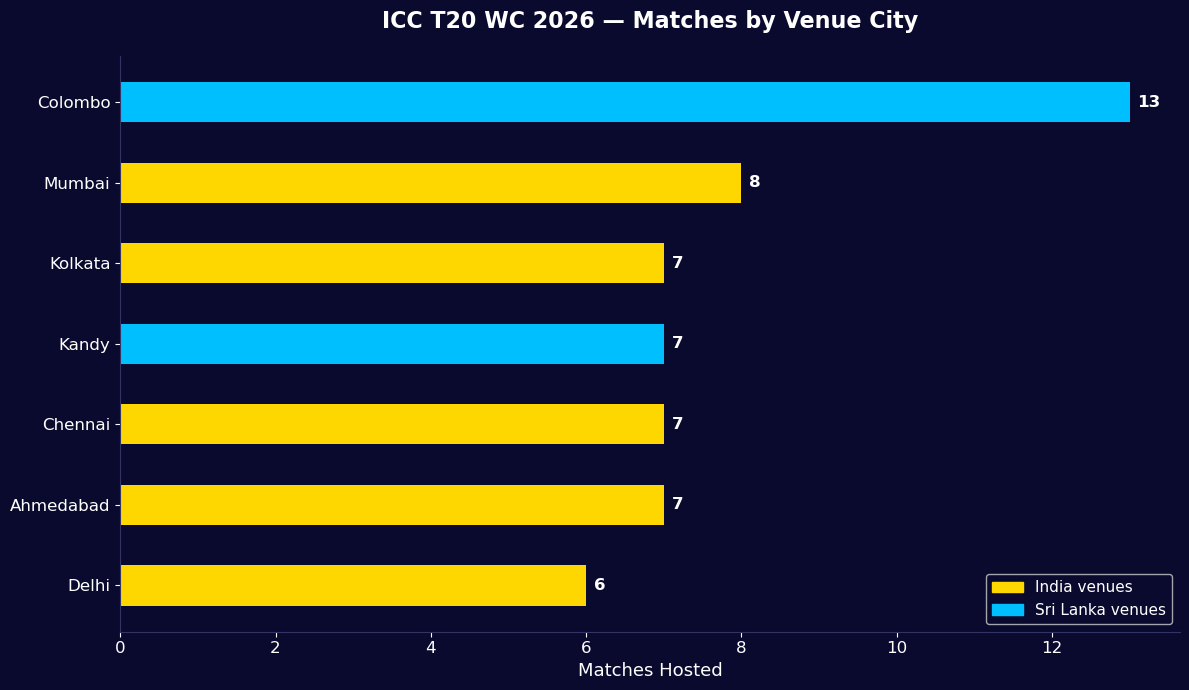

✅ Chart 5 replacement saved!


In [11]:
# Chart 5 REPLACEMENT — Venue Analysis
# Which venues hosted most matches and had 
# highest scoring games

venue_stats = matches.groupby('city').agg(
    matches_hosted=('match_no', 'count'),
).reset_index().sort_values('matches_hosted', ascending=True)

fig, ax = plt.subplots(figsize=(12, 7))
fig.patch.set_facecolor('#0a0a2e')
ax.set_facecolor('#0a0a2e')

colors = ['#FFD700' if city in 
          ['Ahmedabad', 'Mumbai', 'Delhi', 
           'Kolkata', 'Chennai'] 
          else '#00BFFF' 
          for city in venue_stats['city']]

bars = ax.barh(venue_stats['city'], 
               venue_stats['matches_hosted'],
               color=colors, height=0.5)

for bar in bars:
    ax.text(bar.get_width() + 0.1,
            bar.get_y() + bar.get_height()/2,
            str(int(bar.get_width())),
            va='center', color='white',
            fontweight='bold', fontsize=12)

ax.set_xlabel('Matches Hosted', 
              fontsize=13, color='white')
ax.set_title(
    'ICC T20 WC 2026 — Matches by Venue City',
    fontsize=16, color='white',
    fontweight='bold', pad=20
)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#333366')
ax.spines['bottom'].set_color('#333366')
ax.tick_params(colors='white', labelsize=12)

# Legend
india = mpatches.Patch(color='#FFD700', label='India venues')
sl = mpatches.Patch(color='#00BFFF', label='Sri Lanka venues')
ax.legend(handles=[india, sl], 
          facecolor='#0a0a2e',
          labelcolor='white', fontsize=11)

plt.tight_layout()
plt.savefig(
    r'D:\Growth\ICC-T20-WC-2026\venue_analysis.png',
    dpi=150, bbox_inches='tight',
    facecolor='#0a0a2e'
)
plt.show()
print("✅ Chart 5 replacement saved!")

In [8]:
# Check what's happening
print(matches['toss_winner'].isna().sum(), "missing toss winners")
print(matches['toss_decision'].value_counts())
print("\nSample:")
print(matches[['team1','team2','toss_winner',
               'toss_decision','winner']].head(10))

1 missing toss winners
toss_decision
bat      15
field    15
Name: count, dtype: int64

Sample:
          team1        team2   toss_winner toss_decision        winner
0   Netherlands     Pakistan      Pakistan           bat      Pakistan
1   West Indies     Scotland   West Indies           bat   West Indies
2         India          USA         India           bat         India
3   Afghanistan  New Zealand   Afghanistan           bat   New Zealand
4       England        Nepal       England           bat       England
5     Sri Lanka      Ireland     Sri Lanka           bat     Sri Lanka
6      Scotland        Italy      Scotland           bat      Scotland
7          Oman     Zimbabwe      Zimbabwe         field      Zimbabwe
8  South Africa       Canada  South Africa         field  South Africa
9       Namibia  Netherlands   Netherlands           NaN   Netherlands


In [9]:
# Filter only matches where BOTH toss_winner 
# AND toss_decision are available
matches_with_toss = matches_clean[
    matches_clean['toss_decision'].notna() & 
    matches_clean['toss_decision'] != ''
].copy()

print(f"Matches with complete toss data: {len(matches_with_toss)}")
print(matches_with_toss['toss_decision'].value_counts())

# Recalculate
matches_with_toss['toss_won_match'] = (
    matches_with_toss['toss_winner'] == 
    matches_with_toss['winner']
).astype(int)

toss_analysis = matches_with_toss.groupby('toss_decision').agg(
    total=('match_no', 'count'),
    won=('toss_won_match', 'sum')
).reset_index()

toss_analysis['win_pct'] = round(
    toss_analysis['won'] * 100 / toss_analysis['total'], 1
)

print("\nCorrected toss analysis:")
print(toss_analysis)

Matches with complete toss data: 52
toss_decision
bat      15
field    13
Name: count, dtype: int64

Corrected toss analysis:
  toss_decision  total  won  win_pct
0           bat     15   14     93.3
1         field     13   11     84.6


In [10]:
# Let's see exactly which matches have toss data
# and whether toss winner actually won
check = matches_with_toss[['match_no', 'team1', 'team2', 
                            'toss_winner', 'toss_decision', 
                            'winner']].copy()

check['toss_won'] = check['toss_winner'] == check['winner']

# Show all bat matches
print("=== BAT MATCHES ===")
print(check[check['toss_decision'] == 'bat'][[
    'match_no', 'toss_winner', 'winner', 'toss_won'
]].to_string())

print("\n=== FIELD MATCHES ===")
print(check[check['toss_decision'] == 'field'][[
    'match_no', 'toss_winner', 'winner', 'toss_won'
]].to_string())

=== BAT MATCHES ===
    match_no  toss_winner       winner  toss_won
0          1     Pakistan     Pakistan      True
1          2  West Indies  West Indies      True
2          3        India        India      True
3          4  Afghanistan  New Zealand     False
4          5      England      England      True
5          6    Sri Lanka    Sri Lanka      True
6          7     Scotland     Scotland      True
11        12     Pakistan     Pakistan      True
17        18        India        India      True
26        27        India        India      True
34        35     Pakistan     Pakistan      True
35        36        India        India      True
37        38    Sri Lanka    Sri Lanka      True
46        47     Pakistan     Pakistan      True
54        55        India        India      True

=== FIELD MATCHES ===
    match_no   toss_winner        winner  toss_won
7          8      Zimbabwe      Zimbabwe      True
8          9  South Africa  South Africa      True
12        13  South 